Files read: 30
Replicates used: 30
Initial epoch: 1
Final epoch: 5000
Delta initial: 348.04 ± 124.36
Delta final:   28.18 ± 5.57
Reduction:     91.20% ± 2.74%


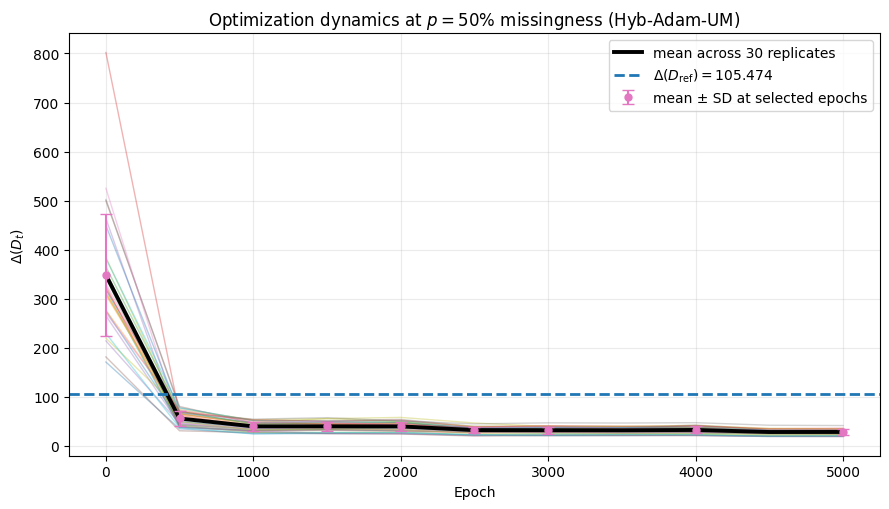

Saved: images/opt_dynamics_p50_30reps.png
Saved: images/opt_dynamics_p50_30reps.pdf


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Settings
# =========================
LOG_DIR = Path("hyb_adam_um_outputs/logs/epoch_logs")
PATTERN = "HybAdamUM_completed_p50_rep*_seed*_epochs.csv"

DELTA_COL = "full_delta"      # use "best_delta" for monotone best-so-far curves
DELTA_REF = 105.474           # Delta(D_ref)
P_MISSING = 50

OUT_DIR = Path("images")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "opt_dynamics_p50_30reps.png"
OUT_PDF = OUT_DIR / "opt_dynamics_p50_30reps.pdf"


# =========================
# Helpers
# =========================
def extract_rep_id(path: Path) -> int:
    """
    Extract replicate number from names like:
    HybAdamUM_completed_p50_rep28_seed82_epochs.csv
    """
    m = re.search(r"_rep(\d+)_", path.name)
    if m is None:
        return 10**9
    return int(m.group(1))


# =========================
# Read files
# =========================
files = sorted(LOG_DIR.glob(PATTERN), key=extract_rep_id)

if len(files) == 0:
    raise FileNotFoundError(f"No files found in {LOG_DIR} with pattern {PATTERN}")

if len(files) != 30:
    print(f"Warning: found {len(files)} files, expected 30.")

all_runs = []

for f in files:
    df = pd.read_csv(f)

    required = {"epoch", DELTA_COL}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{f} is missing columns: {missing}")

    rep_id = extract_rep_id(f)

    tmp = df[["epoch", DELTA_COL]].copy()
    tmp = tmp.rename(columns={DELTA_COL: "delta"})
    tmp["rep"] = rep_id
    tmp["file"] = f.name

    # If the log contains multiple restarts/checkpoints with duplicate epochs,
    # keep the last entry for each epoch within this replicate.
    tmp = tmp.sort_values("epoch").drop_duplicates(subset=["rep", "epoch"], keep="last")

    all_runs.append(tmp)

data = pd.concat(all_runs, ignore_index=True)

# Mean and SD across replicates at each logged epoch
summary = (
    data.groupby("epoch")["delta"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("epoch")
)

# Selected epochs for error bars.
# If your logs contain only checkpoint epochs, this automatically uses them.
available_epochs = summary["epoch"].to_numpy()

preferred_epochs = np.array([1, 100, 200, 300, 500, 700, 1000, 1500, 2000, 2500, 3000, 4000, 5000])
selected_epochs = [e for e in preferred_epochs if e in set(available_epochs)]

# Fallback: use all available epochs if few are logged.
if len(selected_epochs) < 4:
    selected_epochs = available_epochs.tolist()

selected = summary[summary["epoch"].isin(selected_epochs)].copy()


# =========================
# Reduction statistics
# =========================
first_epoch = summary["epoch"].min()
last_epoch = summary["epoch"].max()

initial = data[data["epoch"] == first_epoch].groupby("rep")["delta"].last()
final = data[data["epoch"] == last_epoch].groupby("rep")["delta"].last()

common_reps = initial.index.intersection(final.index)
reduction = (initial.loc[common_reps] - final.loc[common_reps]) / initial.loc[common_reps] * 100.0

print(f"Files read: {len(files)}")
print(f"Replicates used: {len(common_reps)}")
print(f"Initial epoch: {first_epoch}")
print(f"Final epoch: {last_epoch}")
print(f"Delta initial: {initial.loc[common_reps].mean():.2f} ± {initial.loc[common_reps].std():.2f}")
print(f"Delta final:   {final.loc[common_reps].mean():.2f} ± {final.loc[common_reps].std():.2f}")
print(f"Reduction:     {reduction.mean():.2f}% ± {reduction.std():.2f}%")


# =========================
# Plot
# =========================
plt.figure(figsize=(9.0, 5.2))

# Individual replicate trajectories
for rep_id, g in data.groupby("rep"):
    g = g.sort_values("epoch")
    plt.plot(
        g["epoch"],
        g["delta"],
        linewidth=1.0,
        alpha=0.35,
    )

# Mean curve
plt.plot(
    summary["epoch"],
    summary["mean"],
    linewidth=2.8,
    color="black",
    label=f"mean across {len(common_reps)} replicates",
)

# Reference line
plt.axhline(
    DELTA_REF,
    linestyle="--",
    linewidth=2.0,
    color="tab:blue",
    label=rf"$\Delta(D_{{\mathrm{{ref}}}})={DELTA_REF:.3f}$",
)

# Mean ± SD error bars
plt.errorbar(
    selected["epoch"],
    selected["mean"],
    yerr=selected["std"],
    fmt="o",
    markersize=5,
    capsize=4,
    linewidth=1.5,
    color="tab:pink",
    ecolor="tab:pink",
    label="mean ± SD at selected epochs",
)

plt.xlabel("Epoch")
plt.ylabel(r"$\Delta(D_t)$")
plt.title(rf"Optimization dynamics at $p={P_MISSING}\%$ missingness (Hyb-Adam-UM)")

plt.grid(alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300)
plt.savefig(OUT_PDF)
plt.show()

print(f"Saved: {OUT_PNG}")
print(f"Saved: {OUT_PDF}")

Optimization dynamics summary
Files found:        30
Replicates used:    30
Delta column:       full_delta
Initial epoch:      1
Final epoch:        5000
Original Delta:     58.523957

Initial Delta:      348.035134 ± 124.364271
Final Delta:        28.183063 ± 5.573726
Reduction:          91.20% ± 2.74%


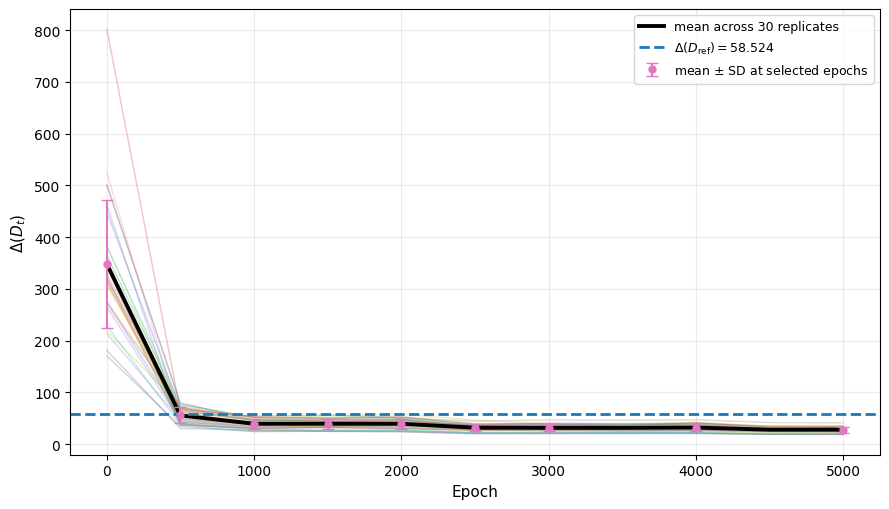

Saved PNG: images/opt_dynamics_p50_30reps.png
Saved PDF: images/opt_dynamics_p50_30reps.pdf
Saved summary CSV: images/opt_dynamics_p50_30reps_summary.csv


In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

LOG_DIR = Path("hyb_adam_um_outputs/logs/epoch_logs")
PATTERN = "HybAdamUM_completed_p50_rep*_seed*_epochs.csv"

# Column to plot from epoch logs.
# Use "full_delta" for actual Delta(D_t).
# Use "best_delta" only if you want monotone best-so-far curves.
DELTA_COL = "full_delta"

P_MISSING = 50

# Reference score of the original complete matrix
ORIGINAL_DELTA_TOTAL = 58.523957

OUT_DIR = Path("images")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "opt_dynamics_p50_30reps.png"
OUT_PDF = OUT_DIR / "opt_dynamics_p50_30reps.pdf"
OUT_CSV = OUT_DIR / "opt_dynamics_p50_30reps_summary.csv"


# ============================================================
# Helper functions
# ============================================================

def extract_rep_id(path: Path) -> int:
    """
    Extract replicate number from file names like:
    HybAdamUM_completed_p50_rep28_seed82_epochs.csv
    """
    m = re.search(r"_rep(\d+)_", path.name)
    if m is None:
        return 10**9
    return int(m.group(1))


def read_epoch_log(path: Path, delta_col: str) -> pd.DataFrame:
    """
    Read one epoch log and return columns:
    rep, epoch, delta, file.
    """
    df = pd.read_csv(path)

    required_cols = {"epoch", delta_col}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"File {path} is missing required columns: {missing_cols}. "
            f"Available columns are: {list(df.columns)}"
        )

    rep_id = extract_rep_id(path)

    out = df[["epoch", delta_col]].copy()
    out = out.rename(columns={delta_col: "delta"})
    out["rep"] = rep_id
    out["file"] = path.name

    # In case the log accidentally contains duplicate epochs,
    # keep the last value for that epoch.
    out = (
        out.sort_values(["rep", "epoch"])
        .drop_duplicates(subset=["rep", "epoch"], keep="last")
        .reset_index(drop=True)
    )

    return out


# ============================================================
# Read all 30 epoch logs
# ============================================================

files = sorted(LOG_DIR.glob(PATTERN), key=extract_rep_id)

if len(files) == 0:
    raise FileNotFoundError(
        f"No files found in:\n  {LOG_DIR}\nwith pattern:\n  {PATTERN}"
    )

if len(files) != 30:
    print(f"Warning: found {len(files)} files, expected 30.")

runs = [read_epoch_log(f, DELTA_COL) for f in files]
data = pd.concat(runs, ignore_index=True)

# Keep only valid numeric values
data["epoch"] = pd.to_numeric(data["epoch"], errors="coerce")
data["delta"] = pd.to_numeric(data["delta"], errors="coerce")
data = data.dropna(subset=["epoch", "delta"]).copy()

data["epoch"] = data["epoch"].astype(int)


# ============================================================
# Compute mean and SD across replicates
# ============================================================

summary = (
    data.groupby("epoch")["delta"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
    .sort_values("epoch")
)

summary.to_csv(OUT_CSV, index=False)


# ============================================================
# Select epochs for error bars
# ============================================================

available_epochs = set(summary["epoch"].tolist())

preferred_epochs = [
    0, 1, 100, 200, 300, 500, 700,
    1000, 1500, 2000, 2500, 3000,
    4000, 5000
]

selected_epochs = [e for e in preferred_epochs if e in available_epochs]

# Fallback: if logs contain different checkpoint epochs,
# take about 8 evenly spaced available epochs.
if len(selected_epochs) < 4:
    all_epochs = summary["epoch"].to_numpy()
    idx = np.linspace(0, len(all_epochs) - 1, min(8, len(all_epochs))).round().astype(int)
    selected_epochs = sorted(set(all_epochs[idx].tolist()))

selected = summary[summary["epoch"].isin(selected_epochs)].copy()


# ============================================================
# Print reduction statistics
# ============================================================

first_epoch = summary["epoch"].min()
last_epoch = summary["epoch"].max()

initial = (
    data[data["epoch"] == first_epoch]
    .groupby("rep")["delta"]
    .last()
)

final = (
    data[data["epoch"] == last_epoch]
    .groupby("rep")["delta"]
    .last()
)

common_reps = initial.index.intersection(final.index)

reduction = (
    (initial.loc[common_reps] - final.loc[common_reps])
    / initial.loc[common_reps]
    * 100.0
)

print("=" * 70)
print("Optimization dynamics summary")
print("=" * 70)
print(f"Files found:        {len(files)}")
print(f"Replicates used:    {len(common_reps)}")
print(f"Delta column:       {DELTA_COL}")
print(f"Initial epoch:      {first_epoch}")
print(f"Final epoch:        {last_epoch}")
print(f"Original Delta:     {ORIGINAL_DELTA_TOTAL:.6f}")
print()
print(
    f"Initial Delta:      "
    f"{initial.loc[common_reps].mean():.6f} "
    f"± {initial.loc[common_reps].std():.6f}"
)
print(
    f"Final Delta:        "
    f"{final.loc[common_reps].mean():.6f} "
    f"± {final.loc[common_reps].std():.6f}"
)
print(
    f"Reduction:          "
    f"{reduction.mean():.2f}% "
    f"± {reduction.std():.2f}%"
)
print("=" * 70)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9.0, 5.2))

# Individual replicate curves
for rep_id, g in data.groupby("rep"):
    g = g.sort_values("epoch")
    plt.plot(
        g["epoch"],
        g["delta"],
        linewidth=1.0,
        alpha=0.28,
    )

# Mean trajectory
plt.plot(
    summary["epoch"],
    summary["mean"],
    color="black",
    linewidth=2.8,
    label=f"mean across {len(common_reps)} replicates",
)

# Original complete-matrix Delta
plt.axhline(
    ORIGINAL_DELTA_TOTAL,
    color="tab:blue",
    linestyle="--",
    linewidth=2.0,
    label=rf"$\Delta(D_{{\mathrm{{ref}}}})={ORIGINAL_DELTA_TOTAL:.3f}$",
)

# Mean ± SD error bars
plt.errorbar(
    selected["epoch"],
    selected["mean"],
    yerr=selected["std"],
    fmt="o",
    markersize=5,
    capsize=4,
    linewidth=1.5,
    color="tab:pink",
    ecolor="tab:pink",
    label=r"mean $\pm$ SD at selected epochs",
)

plt.xlabel("Epoch", fontsize=11)
plt.ylabel(r"$\Delta(D_t)$", fontsize=11)

# For manuscript figures, better not to use a plot title.
# The caption should contain the full explanation.
# plt.title(rf"Optimization dynamics at $p={P_MISSING}\%$ missingness (Hyb-Adam-UM)")

plt.grid(alpha=0.25)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

plt.show()

print(f"Saved PNG: {OUT_PNG}")
print(f"Saved PDF: {OUT_PDF}")
print(f"Saved summary CSV: {OUT_CSV}")